In [1]:
import pandas as pd

data = pd.read_csv('day17-classification.csv')

In [2]:
data.head()

,customer_id,signup_date,age,gender,region,plan_type,monthly_fee,usage_hours,support_calls,late_payments,contract_months,device_type,payment_method,satisfaction_score,churn
0,CUST-00001,2026-02-07,53.0,Female,Daejeon,Standard,85414.0,4.0,3.0,1,12,Android,VirtualAccount,3.0,1
1,CUST-00002,2024-05-17,39.0,Male,Seoul,Basic,69137.0,24.2,3.0,0,24,Android,Mobile,5.0,0
2,CUST-00003,2023-05-01,51.0,Female,Busan,Standard,44323.0,51.4,1.0,0,12,iOS,Card,2.0,0
3,CUST-00004,2024-01-18,65.0,Female,Daegu,Standard,67657.0,82.3,2.0,0,24,iOS,Mobile,5.0,0
4,CUST-00005,2025-10-07,18.0,Female,Busan,Basic,65210.0,58.2,2.0,0,6,Android,Card,3.0,0


In [3]:
data.shape

(1208, 15)

In [6]:
data.dtypes

customer_id               str
signup_date               str
age                   float64
gender                    str
region                    str
plan_type                 str
monthly_fee           float64
usage_hours           float64
support_calls         float64
late_payments           int64
contract_months         int64
device_type               str
payment_method            str
satisfaction_score    float64
churn                   int64
dtype: object

In [7]:
data.isnull().sum()

customer_id            0
signup_date            0
age                   25
gender                 0
region                 0
plan_type              0
monthly_fee            0
usage_hours            0
support_calls         21
late_payments          0
contract_months        0
device_type            0
payment_method        15
satisfaction_score    18
churn                  0
dtype: int64

In [8]:
data.describe()

,age,monthly_fee,usage_hours,support_calls,late_payments,contract_months,satisfaction_score,churn
count,1183.000000,1208.000000,1208.000000,1187.000000,1208.00000,1208.000000,1190.000000,1208.000000
mean,40.919696,63384.131623,39.298510,1.750632,0.81043,10.929636,3.035294,0.119205
std,12.606278,23303.467881,30.989215,1.301895,0.87570,7.656190,1.434443,0.324164
min,18.000000,18000.000000,2.600000,0.000000,0.00000,1.000000,1.000000,0.000000
25%,32.000000,50513.000000,22.600000,1.000000,0.00000,6.000000,2.000000,0.000000
50%,41.000000,62487.500000,33.800000,2.000000,1.00000,12.000000,3.000000,0.000000
75%,50.000000,73573.000000,49.225000,3.000000,1.00000,12.000000,4.000000,0.000000
max,79.000000,277420.000000,387.000000,8.000000,5.00000,24.000000,5.000000,1.000000


In [9]:
data['churn'].value_counts()

churn
0    1064
1     144
Name: count, dtype: int64

In [10]:
data['churn'].value_counts(normalize=True)

churn
0    0.880795
1    0.119205
Name: proportion, dtype: float64

In [12]:
data.duplicated().sum()

np.int64(8)

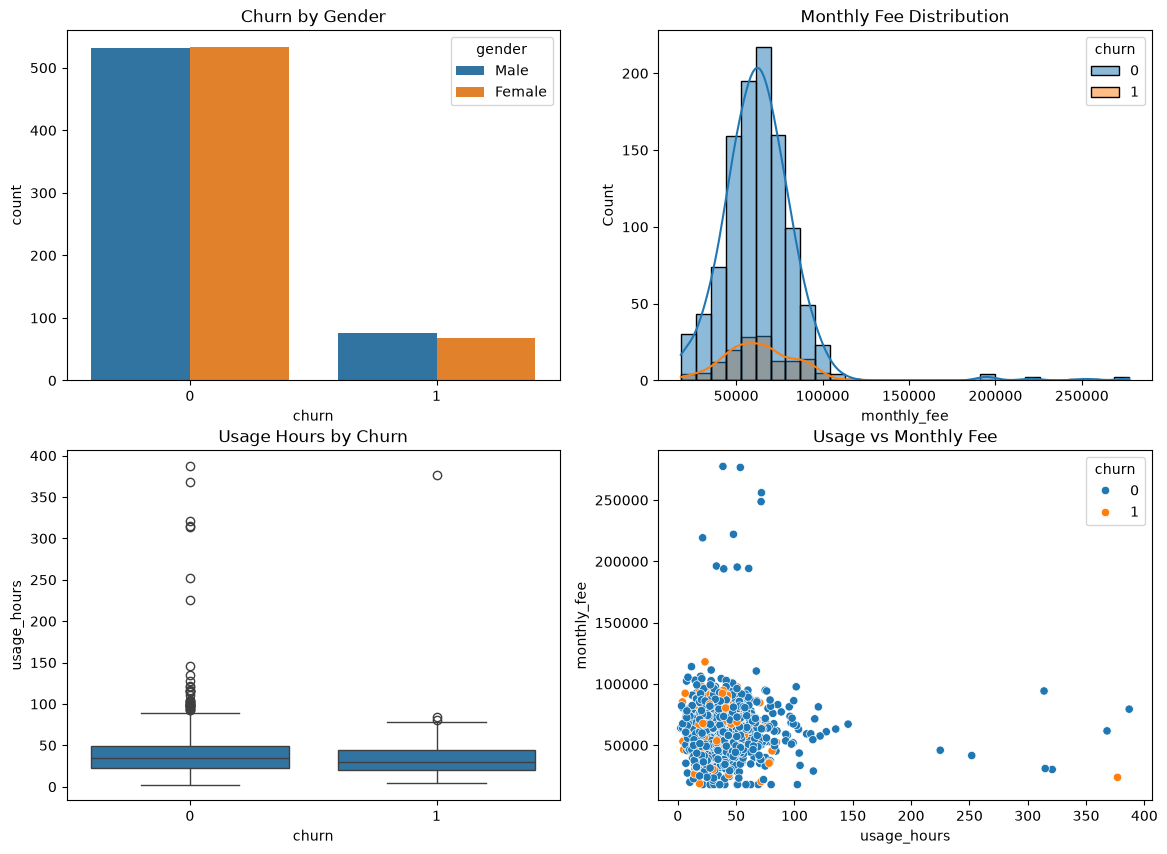

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,10))

sns.countplot(data=data, x='churn', hue='gender', ax=axes[0][0])
sns.histplot(data=data, x='monthly_fee', hue='churn', ax=axes[0][1], bins=30, kde=True)
sns.boxplot(data=data, x='churn', y='usage_hours', ax=axes[1][0])
sns.scatterplot(data=data, x='usage_hours', y='monthly_fee', hue='churn', ax=axes[1][1])

axes[0][0].set_title('Churn by Gender')
axes[0][1].set_title('Monthly Fee Distribution')
axes[1][0].set_title('Usage Hours by Churn')
axes[1][1].set_title('Usage vs Monthly Fee')

plt.show()

In [30]:
data_clean = data.copy()

In [31]:
data = data.drop_duplicates()

In [32]:
data.shape

(1200, 15)

In [37]:
data['age'] = data['age'].fillna(data['age'].median())
data['support_calls'] = data['support_calls'].fillna(data['support_calls'].median())
data['satisfaction_score'] = data['satisfaction_score'].fillna(data['satisfaction_score'].mode()[0])
data['payment_method'] = data['payment_method'].fillna(data['payment_method'].mode()[0])

print(data.shape[0])
print(data.duplicated().sum())
print(data.isnull().sum())

1200
0
customer_id           0
signup_date           0
age                   0
gender                0
region                0
plan_type             0
monthly_fee           0
usage_hours           0
support_calls         0
late_payments         0
contract_months       0
device_type           0
payment_method        0
satisfaction_score    0
churn                 0
dtype: int64


In [38]:
data = data.drop(data[data['monthly_fee']>=150000].index)

In [40]:
Q1 = data['usage_hours'].quantile(0.25)
Q3 = data['usage_hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [52]:
data = data.drop(
    data[
        (data['usage_hours']<lower)|
        (data['usage_hours']>upper)
    ].index # 삭제할 행의 인덱스 필요
)

# 삭제가 아닌 남길 조건도 가능
# data = data[
#     (data['usage_hours']>=lower)&
#     (data['usage_hours']<=upper)
# ]

In [53]:
print(data.shape)
print(data['monthly_fee'].max())
print(data['usage_hours'].min())
print(data['usage_hours'].max())

(1154, 15)
118085.0
2.6
88.7


In [56]:
data['signup_date'] = pd.to_datetime(data['signup_date'])

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month
data['signup_dayofweek'] = data['signup_date'].dt.day_of_week # 0 ~ 6
data['signup_weekend'] = data['signup_dayofweek'].isin([5,6])

data = data.drop(columns=['customer_id'])
data = data.drop(columns=['signup_date'])

In [63]:
data.head()

,age,gender,region,plan_type,monthly_fee,usage_hours,support_calls,late_payments,contract_months,device_type,payment_method,satisfaction_score,churn,signup_year,signup_month,signup_dayofweek,signup_weekend
0,53.0,Female,Daejeon,Standard,85414.0,4.0,3.0,1,12,Android,VirtualAccount,3.0,1,2026,2,5,1
1,39.0,Male,Seoul,Basic,69137.0,24.2,3.0,0,24,Android,Mobile,5.0,0,2024,5,4,0
2,51.0,Female,Busan,Standard,44323.0,51.4,1.0,0,12,iOS,Card,2.0,0,2023,5,0,0
3,65.0,Female,Daegu,Standard,67657.0,82.3,2.0,0,24,iOS,Mobile,5.0,0,2024,1,3,0
4,18.0,Female,Busan,Basic,65210.0,58.2,2.0,0,6,Android,Card,3.0,0,2025,10,1,0


In [61]:
data['signup_weekend'] = data['signup_weekend'].astype(int)

In [62]:
data.dtypes

age                   float64
gender                    str
region                    str
plan_type                 str
monthly_fee           float64
usage_hours           float64
support_calls         float64
late_payments           int64
contract_months         int64
device_type               str
payment_method            str
satisfaction_score    float64
churn                   int64
signup_year             int32
signup_month            int32
signup_dayofweek        int64
signup_weekend          int64
dtype: object

In [ ]:
# Label Encoder = 숫자 0, 1, 2 등등으로 들어가서 모델이 숫자적 서열이 있다고 판단할 수 있음 - get_dummies 사용
print(data['gender'].value_counts()) # 0, 1 가능 - map
print(data['region'].value_counts())
print(data['plan_type'].value_counts()) # 명확한 등급 - map
print(data['device_type'].value_counts())
print(data['payment_method'].value_counts())

gender
Male      579
Female    575
Name: count, dtype: int64
region
Seoul      404
Busan      245
Incheon    185
Daejeon    161
Daegu      159
Name: count, dtype: int64
plan_type
Standard    501
Basic       397
Premium     256
Name: count, dtype: int64
device_type
Android    557
iOS        431
Web        166
Name: count, dtype: int64
payment_method
VirtualAccount    326
Mobile            283
Card              273
BankTransfer      272
Name: count, dtype: int64


In [69]:
data['gender'] = data['gender'].map({
    'Male':0,
    'Female':1
})

data['plan_type'] = data['plan_type'].map({
    'Basic':0,
    'Standard':1,
    'Premium':2
})

data = pd.get_dummies(data, columns=['region', 'device_type', 'payment_method'], drop_first=True)

data_encoded = data.copy()

data_encoded.info()

<class 'pandas.DataFrame'>
Index: 1154 entries, 0 to 1199
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1154 non-null   float64
 1   gender                         1154 non-null   int64  
 2   plan_type                      1154 non-null   int64  
 3   monthly_fee                    1154 non-null   float64
 4   usage_hours                    1154 non-null   float64
 5   support_calls                  1154 non-null   float64
 6   late_payments                  1154 non-null   int64  
 7   contract_months                1154 non-null   int64  
 8   satisfaction_score             1154 non-null   float64
 9   churn                          1154 non-null   int64  
 10  signup_year                    1154 non-null   int32  
 11  signup_month                   1154 non-null   int32  
 12  signup_dayofweek               1154 non-null   int64  
 13  sign

In [71]:
data_encoded.rename(columns={'support_calls':'support_count'}, inplace=True)

X = data_encoded.drop(columns=['churn'])
y = data_encoded['churn']

print(X.shape)
print(y.shape)

(1154, 22)
(1154,)


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_valid.value_counts(normalize=True))

churn
0    0.87695
1    0.12305
Name: proportion, dtype: float64
churn
0    0.87649
1    0.12351
Name: proportion, dtype: float64
churn
0    0.878788
1    0.121212
Name: proportion, dtype: float64


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train, y_train)
X_valid_scaled = scaler.transform(X_valid)

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import recall_score, f1_score, precision_score

lr = LogisticRegression(random_state=42,class_weight='balanced')

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_valid_scaled)

print(accuracy_score(y_valid, y_pred_lr))
print(recall_score(y_valid, y_pred_lr))
print(precision_score(y_valid, y_pred_lr))
print(f1_score(y_valid, y_pred_lr))
print(confusion_matrix(y_valid, y_pred_lr))
print(classification_report(y_valid, y_pred_lr))

0.696969696969697
0.7142857142857143
0.24390243902439024
0.36363636363636365
[[141  62]
 [  8  20]]
              precision    recall  f1-score   support

           0       0.95      0.69      0.80       203
           1       0.24      0.71      0.36        28

    accuracy                           0.70       231
   macro avg       0.60      0.70      0.58       231
weighted avg       0.86      0.70      0.75       231



In [86]:
lr_2 = LogisticRegression()

lr_2.fit(X_train_scaled, y_train)
# 0 / 1 일 확률
lr_proba = lr_2.predict_proba(X_valid_scaled)
# 1일 확률
lr_proba_1 = lr_proba[:,1]

# 임계값 조정
lr_proba_03 = (lr_proba_1 >= 0.3).astype(int)
lr_proba_03

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [85]:
print(confusion_matrix(y_valid, lr_proba_03))
print(precision_score(y_valid, lr_proba_03))
print(recall_score(y_valid, lr_proba_03))
print(f1_score(y_valid, lr_proba_03))

[[194   9]
 [ 22   6]]
0.4
0.21428571428571427
0.27906976744186046


In [ ]:
from sklearn.metrics import roc_auc_score

# 실제 1에 값을 더 잘 주고 있는지
roc_auc_score(y_valid, lr_proba_1)

0.7895847994370162

In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=8,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_valid)

rf_proba = rf.predict_proba(X_valid)
rf_pred_1 = rf_proba[:,1]

print(accuracy_score(y_valid, rf_pred))
print(recall_score(y_valid, rf_pred))
print(precision_score(y_valid, rf_pred))
print(f1_score(y_valid, rf_pred))
print(confusion_matrix(y_valid, rf_pred))
print(classification_report(y_valid, rf_pred))
print(roc_auc_score(y_valid, rf_pred_1))

0.8398268398268398
0.14285714285714285
0.23529411764705882
0.17777777777777778
[[190  13]
 [ 24   4]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       203
           1       0.24      0.14      0.18        28

    accuracy                           0.84       231
   macro avg       0.56      0.54      0.54       231
weighted avg       0.81      0.84      0.82       231

0.7280084447572132


In [94]:
from sklearn.model_selection import GridSearchCV

grid_model = RandomForestClassifier(random_state=42, class_weight='balanced')

params = {
    'n_estimators':[100, 200],
    'max_depth':[4, 8, None],
    'min_samples_split':[2, 10],
    'min_samples_leaf':[1, 5]
    }

grid = GridSearchCV(
    grid_model,
    params,
    cv=5,
    scoring='recall'
)

grid.fit(X_train, y_train);

In [95]:
print(grid.best_estimator_)
print(grid.best_params_)
print(grid.best_score_)

RandomForestClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=5,
                       n_estimators=200, random_state=42)
{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
0.5454545454545455


In [97]:
best_grid = grid.best_estimator_

grid_pred = best_grid.predict(X_valid)

print(confusion_matrix(y_valid, grid_pred))
print(precision_score(y_valid, grid_pred))
print(recall_score(y_valid, grid_pred))
print(f1_score(y_valid, grid_pred))

[[162  41]
 [ 15  13]]
0.24074074074074073
0.4642857142857143
0.3170731707317073


In [98]:
# 이진분류 딥러닝
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [99]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    monitor='val_loss',
    filepath='best_churn_model.keras',
    save_best_only=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data = (X_valid_scaled, y_valid),
    callbacks=[early_stop, checkpoint]   
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8277 - loss: 0.4654 - val_accuracy: 0.8788 - val_loss: 0.3761
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8765 - loss: 0.3736 - val_accuracy: 0.8788 - val_loss: 0.3597
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8765 - loss: 0.3649 - val_accuracy: 0.8788 - val_loss: 0.3488
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8765 - loss: 0.3427 - val_accuracy: 0.8788 - val_loss: 0.3391
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8787 - loss: 0.3294 - val_accuracy: 0.8788 - val_loss: 0.3364
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8797 - loss: 0.3185 - val_accuracy: 0.8831 - val_loss: 0.3337
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8787 - loss: 0.3219 - val_accuracy: 0.8788 - val_loss: 0.3321
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8776 - loss: 0.3164 - val_accuracy: 0.8788 - val_loss:

In [102]:
from tensorflow.keras.models import load_model

best_model = load_model('best_churn_model.keras')

# 이진분류 딥러닝이라 predict 결과가 1일 확률임.
y_proba_dl = best_model.predict(X_valid_scaled)
# 1차원으로 펴줌
y_proba_dl = y_proba_dl.ravel()

y_pred_dl = (y_proba_dl >= 0.5).astype(int)

print(confusion_matrix(y_valid, y_pred_dl))
print(precision_score(y_valid, y_pred_dl))
print(recall_score(y_valid, y_pred_dl))
print(f1_score(y_valid, y_pred_dl))
print(roc_auc_score(y_valid, y_proba_dl))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[202   1]
 [ 27   1]]
0.5
0.03571428571428571
0.06666666666666667
0.7294159042927516


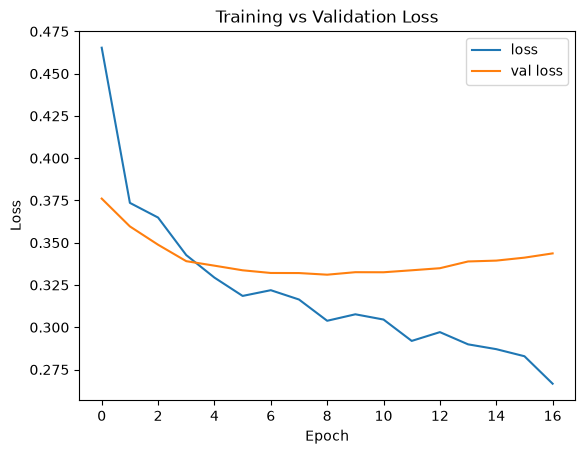

In [104]:
# 학습 그래프
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()